### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load Dataset

In [2]:
df = pd.read_csv("cleaned_dataset.csv")

df.head()

,Voltage_measured,Current_measured,Temperature_measured,Time,Current_charge,Voltage_charge
0,0.256480,0.000246,5.750652,9429.781,0.0000,-0.007
1,4.196348,0.029956,23.737184,9488.016,0.0320,4.224
2,4.170813,1.496499,7.611751,475.610,1.5023,4.968
3,4.213269,0.040591,24.217486,8776.000,0.0419,4.250
4,4.200903,0.001865,5.568730,3800.594,-0.0006,0.002


### Create IMPROVED Target

In [3]:
df["range_loss"] = (
    (25 - df["Temperature_measured"]) * 0.3
    + abs(df["Current_measured"]) * 2
    + (df["Voltage_charge"] - df["Voltage_measured"]) * 1.5
)

### Feature Engineering

In [4]:
df["power"] = df["Voltage_measured"] * df["Current_measured"]
df["current_abs"] = abs(df["Current_measured"])

### Select Features (NO DATA LEAKAGE)

In [5]:
X = df[
    [
        "Voltage_measured",
        "Current_measured",
        "Time",
        "power",
        "current_abs"
    ]
]

y = df["range_loss"]

### Train-Test Split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train Linear Regression

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, lr_pred))

Linear Regression R2: 0.14364357295265218


### Train XGBoost (Improved)

In [8]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost R2:", r2_score(y_test, xgb_pred))

XGBoost R2: 0.6711985288963735


### Feature Importance (IMPORTANT)

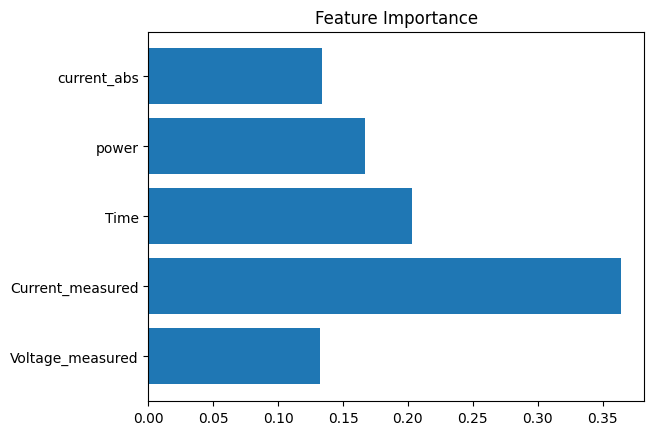

In [9]:
importance = xgb_model.feature_importances_

plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()